# Adult Annual Income Classification

## Business Problem

Predicting an individual's income category from demographic and employment characteristics can help identify patterns associated with higher income levels. This project uses machine learning to classify individuals into two income categories: <= $50K and > $50K.

## Objectives

The main objectives of this project are:

1. Explore and understand the Adult Census Income dataset.
2. Identify and handle missing or inconsistent data.
3. Perform exploratory data analysis (EDA) to discover relationships between features and income.
4. Prepare numerical and categorical features for machine learning.
5. Build a Logistic Regression classification model.
6. Build a Decision Tree classification model.
7. Evaluate both models using multiple classification metrics.
8. Compare the performance of the two models.
9. Identify the most important features for income prediction.
10. Determine which model is more suitable for this classification problem.

## 1. Import Libararies

In [1]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

%matplotlib inline 
sns.set_theme(style="whitegrid")

from ucimlrepo import fetch_ucirepo ,list_available_datasets

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import (LabelEncoder,OneHotEncoder,OrdinalEncoder,
StandardScaler,MinMaxScaler)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC 

from sklearn.metrics import (
accuracy_score,precision_score,recall_score,
f1_score,roc_auc_score,confusion_matrix,classification_report)

import ydata_profiling 
from ydata_profiling import ProfileReport

import warnings 
warnings.filterwarnings('ignore' , category= FutureWarning)

C:\Users\smata\AppData\Local\Temp\ipykernel_27400\1387365384.py:29: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  import ydata_profiling


The required Python libraries are imported for:

- **Pandas & NumPy:** Data manipulation and numerical operations.
- **Matplotlib & Seaborn:** Data visualization and exploratory analysis.
- **Scikit-learn:** Data preprocessing, model building, and model evaluation.

The project will use two classification algorithms: **Logistic Regression** and **Decision Tree Classifier**.

## 2. Load The Dataset

In [2]:
adult = fetch_ucirepo(id=2)

x = adult.data.features
y = adult.data.targets

In [3]:
df = pd.concat([x, y], axis=1)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 3. Data Profiling Report

In [4]:
profile = ProfileReport(df , title = 'Profiling Report' , explorative= True) 
profile.to_file('Adult Annual Income Report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:02<00:00,  6.44it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 4. Data Understanding 

### Data Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


**Dataset Information**

The `info()` method is used to examine:

- Number of observations
- Data types
- Non-null values
- Potential missing values

**Observation:**  
The dataset contains both numerical and categorical features. The categorical variables will need to be encoded before they can be used by the machine learning models.

The output will also help us identify columns that may contain missing values.

### Statistical summary

In [6]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## 5. Data Cleaning

### Remove Extra Spaces

In [7]:
df = df.apply(
    lambda col: col.str.strip() if col.dtype == 'object' else col
)

### Check the missing values

In [8]:
missing_values = df.isnull().sum().sort_values(ascending = False)

print('-- Missing Counts --')
missing_values[missing_values > 0]

-- Missing Counts --


occupation        966
workclass         963
native-country    274
dtype: int64

In [9]:
print('-- Missing Precetages --')

for col in df.columns:
    if (df[col].isnull().sum() > 0):
        print(f'{col} : {(df[col].isnull().mean() * 100).round(2)}')

-- Missing Precetages --
workclass : 1.97
occupation : 1.98
native-country : 0.56


### Convert `?` to Missing Values

In [10]:
df = df.replace("?", np.nan)

print('-- Missing Counts --')

missing_values = df.isnull().sum().sort_values(ascending = False)
missing_values[missing_values > 0]

-- Missing Counts --


occupation        2809
workclass         2799
native-country     857
dtype: int64

In [11]:
print('-- Missing Precetages --')

for col in df.columns:
    if (df[col].isnull().sum() > 0):
        print(f'{col} : {(df[col].isnull().mean() * 100).round(2)}')

-- Missing Precetages --
workclass : 5.73
occupation : 5.75
native-country : 1.75


In [12]:
missing_cols = ["workclass", "occupation", "native-country"]

df[missing_cols] = df[missing_cols].fillna("Unknown")

In [13]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

### Check The Duplicates Rows

In [14]:
df.duplicated().sum()

np.int64(29)

In [15]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(48813, 15)

Duplicates can affect the analysis and potentially influence model training.

So we checked how many duplicate rows exist and decided to delete them as it's just 29 rows from 48813 rows.

### Clean and encoding the target column

In [17]:
df['income'].value_counts()

income
<=50K     24698
<=50K.    12430
>50K       7839
>50K.      3846
Name: count, dtype: int64

In [18]:
df['income'] = df['income'].replace({
    '<=50K' : '<=50K', 
    '<=50K.' : '<=50K', 
    '>50K' : '>50K', 
    '>50K.' : '>50K'
})

df['income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [19]:
df["income"].value_counts(normalize=True) * 100

income
<=50K    76.061705
>50K     23.938295
Name: proportion, dtype: float64

In [20]:
df["income"] = df["income"].map({
    '<=50K' : 0 ,
    '>50K' : 1 
})

### Remove `education` column 
as it's duplicated there's `education-num` column that is substitute it

In [21]:
df = df.drop('education' , axis= 1)

In [22]:
df.columns.to_list()

['age',
 'workclass',
 'fnlwgt',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'income']

## 6. Feauter Enginering

Feature engineering involves creating new features from existing variables to provide the machine learning models with additional useful information.

In this project, we will create features related to:

- Age groups
- Capital gains (income/profit received from investments rather than from a normal job)
- Capital losses (money lost from investments)
- Working hours

In [23]:
print(f'min age : {df['age'].min()}')
print(f'max age : {df['age'].max()}')

min age : 17
max age : 90


In [24]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 55, 65, float('inf')],
    labels=[
        "Young",
        "Early_Adult",
        "Adult",
        "Senior",
        "Older"
    ], 
    include_lowest=True
)

In [25]:
df['has_capital_gain'] = (df["capital-gain"] > 0).astype(int)
df['has_capital_loss'] = (df["capital-loss"] > 0).astype(int)

In [26]:
df["work_hours_group"] = pd.cut(
    df["hours-per-week"],
    bins=[0, 20, 40, float('inf')],
    labels=[
        "Part-time",
        "Full-time",
        "Overtime",
    ]
)

In [27]:
df[['age_group','has_capital_gain','has_capital_loss','work_hours_group']].head(10)

,age_group,has_capital_gain,has_capital_loss,work_hours_group
0,Adult,1,0,Full-time
1,Adult,0,0,Part-time
2,Adult,0,0,Full-time
3,Adult,0,0,Full-time
4,Early_Adult,0,0,Full-time
5,Adult,0,0,Full-time
6,Adult,0,0,Part-time
7,Adult,0,0,Overtime
8,Early_Adult,1,0,Overtime
9,Adult,1,0,Full-time


## 7. Boxplots and Potential Outliers

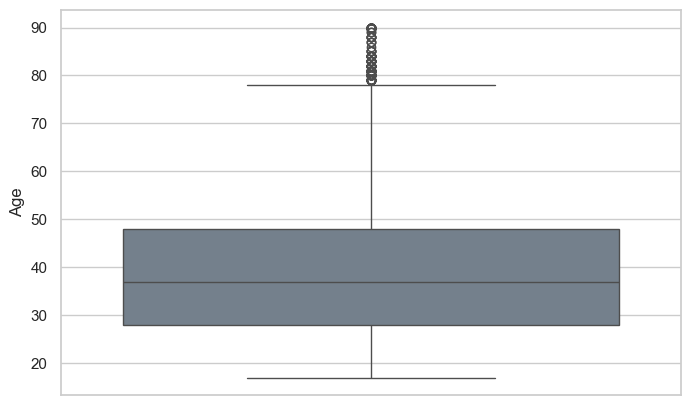

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(data= df ,y='age' , color= 'slategray')

plt.ylabel('Age')

plt.show()

In [29]:
q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)

IQR = q3 - q1 

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -2.0
Upper bound: 78.0


In [30]:
age_outliers = df[
    (df["age"] < lower_bound) |
    (df["age"] > upper_bound)
]

age_outliers["age"].describe()

count    215.000000
mean      83.627907
std        4.246072
min       79.000000
25%       80.000000
50%       82.000000
75%       89.500000
max       90.000000
Name: age, dtype: float64

In [31]:
df["age"].min(), df["age"].max()

(17, 90)

### Insight 
After checking the age distribution and outliers , found that there is no any values that considers as outlier as: 

(Min Age -> 17) & (Max Age -> 90)

## 8. Identify Numerical and Categorical Features

In [32]:
numeric_features = [
    'age', 
    'fnlwgt',
    'education-num' , 
    'capital-gain',
    'capital-loss', 
    'hours-per-week'
]

nominal_features = [
    'workclass', 
    'marital-status', 
    'occupation', 
    'relationship', 
    'race', 
    'sex', 
    'native-country'
  ]

ordinal_features = [
    'age_group', 
    'work_hours_group'
]

In [33]:
ordinal_categories = [
    ["Young", "Early_Adult", "Adult", "Senior", "Older"],
    ["Part-time", "Full-time", "Overtime"]
]

## 9.  Data Preprocessing

### select Featuers & Target

In [34]:
x = df.drop('income' , axis=1)
y = df['income']

### Train / Test Split

In [35]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [36]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),

        ("ordinal", OrdinalEncoder(
            categories=ordinal_categories
        ), ordinal_features),

        ("nominal", OneHotEncoder(
            handle_unknown="ignore"
        ), nominal_features)
    ]
)

Two preprocessing techniques are applied:

**Numerical Features — StandardScaler**
Numerical features are standardized so that they have comparable scales.

**Categorical(Nominal) Features — OneHotEncoder**
**Categorical(Ordinal) Features — LabelEncoder**
Categorical variables are converted into numerical features that machine learning algorithms can process.

`handle_unknown="ignore"` ensures that the model can handle categories appearing in the test data that were not present during training.

**Key Insight:**  
Preprocessing is fitted as part of the machine learning pipeline using only the training data, which helps prevent data leakage.

## 10. Logistic Regression Model

### Train Logistic Regression

In [37]:
logreg = Pipeline(
    steps= [
        ('preprocessor' , preprocessor),
        ('model' , LogisticRegression(max_iter=1000))
    ]
)

logreg.fit(x_train , y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Logistic Regression Predictions

In [38]:
y_pred_logreg = logreg.predict(x_test)
y_prob_logreg = logreg.predict_proba(x_test)[:, 1]

The trained Logistic Regression model is used to make predictions on the unseen test set.

Two outputs are generated:

- `y_pred_logreg`: The predicted class (`0` or `1`).
- `y_prob_logreg`: The predicted probability of belonging to the `>50K` class.

The probability predictions will be used to calculate the ROC-AUC score.

### Logistic Regression Evaluation

In [39]:
accuracy_logreg = accuracy_score(y_test , y_pred_logreg)
precision_logreg = precision_score(y_test , y_pred_logreg)
recall_logreg = recall_score(y_test , y_pred_logreg) 
f1_logreg = f1_score(y_test , y_pred_logreg) 
roc_auc_logreg = roc_auc_score(y_test , y_pred_logreg)

In [40]:
print("Accuracy:", accuracy_logreg)
print("Precision:", precision_logreg)
print("Recall:", recall_logreg)
print("F1 Score:", f1_logreg)
print("ROC-AUC:", roc_auc_logreg)

Accuracy: 0.8560893168083581
Precision: 0.7432150313152401
Recall: 0.6093281985451433
F1 Score: 0.6696449565012932
ROC-AUC: 0.7715372476700939


**Conclusion**

Overall, the Logistic Regression model provides a good baseline with **85.61% accuracy** and **77.15% ROC-AUC**. However, the relatively lower recall suggests that the model could be improved in identifying individuals with income **>50K**.

### Confusion Matrix — Logistic Regression

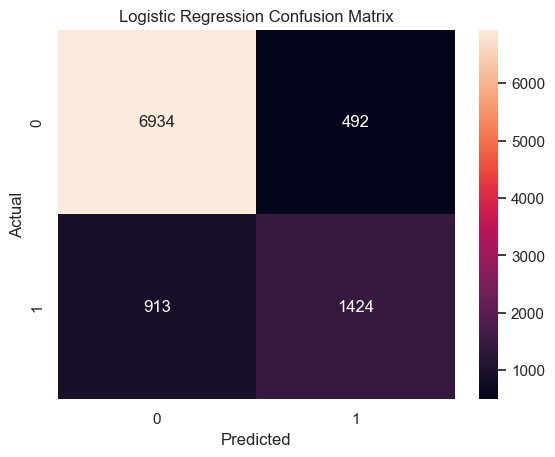

In [41]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

sns.heatmap(cm_logreg, annot=True, fmt="d")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Observation:**  
The confusion matrix allows us to understand the types of errors made by the model rather than relying only on a single performance score.

### Classification Report

In [42]:
class_report_logreg = classification_report(y_test, y_pred_logreg)
print(class_report_logreg)

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      7426
           1       0.74      0.61      0.67      2337

    accuracy                           0.86      9763
   macro avg       0.81      0.77      0.79      9763
weighted avg       0.85      0.86      0.85      9763



**Insight**

The Logistic Regression model performs better on the <=50K class, achieving a recall of 93% and an F1-score of 91%. However, its performance on the >50K class is weaker, particularly in recall (61%), meaning that the model fails to identify a considerable proportion of high-income individuals.

This is important because the dataset is imbalanced and performance may differ considerably between the majority and minority classes.

## 11. Decision Tree Model

### Train Decision Tree

In [43]:
dectree = Pipeline(
    steps=[
        ('preprocessor',preprocessor), 
        ('model' , DecisionTreeClassifier(random_state=42))
    ]
)

dectree.fit(x_train , y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Decision Tree Predictions

In [44]:
y_pred_dectree = dectree.predict(x_test)
y_prob_dctree = dectree.predict_proba(x_test)[:,1]

### Decision Tree Evaluation

In [45]:
accuracy_dectree = accuracy_score(y_test , y_pred_dectree)
precision_dectree = precision_score(y_test , y_pred_dectree)
recall_dectree = recall_score(y_test , y_pred_dectree) 
f1_dectree = f1_score(y_test , y_pred_dectree) 
roc_auc_dectree = roc_auc_score(y_test , y_pred_dectree)

In [46]:
print("Accuracy:", accuracy_dectree)
print("Precision:", precision_dectree)
print("Recall:", recall_dectree)
print("F1 Score:", f1_dectree)
print("ROC-AUC:", roc_auc_dectree)

Accuracy: 0.8157328689951859
Precision: 0.6129303106633082
Recall: 0.6247325631151048
F1 Score: 0.6187751642297097
ROC-AUC: 0.7502871003025026


**Conclusion**

Overall, the Decision Tree achieved **81.57% accuracy** and a **75.03% ROC-AUC**. Although it was able to identify a reasonable proportion of individuals earning more than $50K, its precision and F1-score were relatively low. Therefore, the model has room for improvement in both reducing false positive predictions and improving the overall classification of the higher-income class.

### Confusion Matrix — Logistic Regression

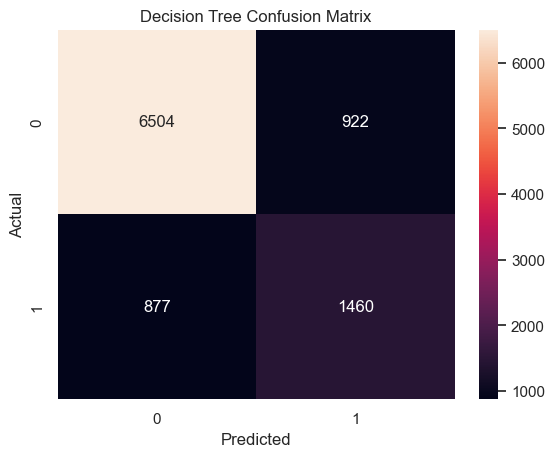

In [47]:
cm_dectree = confusion_matrix(y_test , y_pred_dectree)

sns.heatmap(cm_dectree ,annot=True, fmt = 'd')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Classification Report

In [48]:
class_report_dectree = classification_report(y_test, y_pred_dectree)
print(class_report_dectree)

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      7426
           1       0.61      0.62      0.62      2337

    accuracy                           0.82      9763
   macro avg       0.75      0.75      0.75      9763
weighted avg       0.82      0.82      0.82      9763



**Insight**

The Decision Tree model performs better on the <=50K class, achieving a recall of 88% and an F1-score of 88%. meaning that the model fails to identify a considerable proportion of high-income individuals.

This is important because the dataset is imbalanced and performance may differ considerably between the majority and minority classes.

## 12. Compare the Models

### Comparison Table

In [49]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_logreg,
        accuracy_dectree
    ],
    "Precision": [
        precision_logreg,
        precision_dectree
    ],
    "Recall": [
        recall_logreg,
        recall_dectree
    ],
    "F1 Score": [
        f1_logreg,
        f1_dectree
    ],
    "ROC-AUC": [
        roc_auc_logreg,
        roc_auc_dectree
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.856089,0.743215,0.609328,0.669645,0.771537
1,Decision Tree,0.815733,0.612930,0.624733,0.618775,0.750287


#### Comparison Insights

- **Logistic Regression** achieved higher **Accuracy, Precision, F1 Score, and ROC-AUC**.
- **Decision Tree** achieved slightly higher **Recall**, identifying a slightly larger proportion of individuals whose income is greater than $50K.
- The difference in Recall between the two models is relatively small.
- Overall, the results show that the two models have similar performance in identifying the `>50K` class, but they differ in their balance between precision and recall.

### Visualization of Comparison

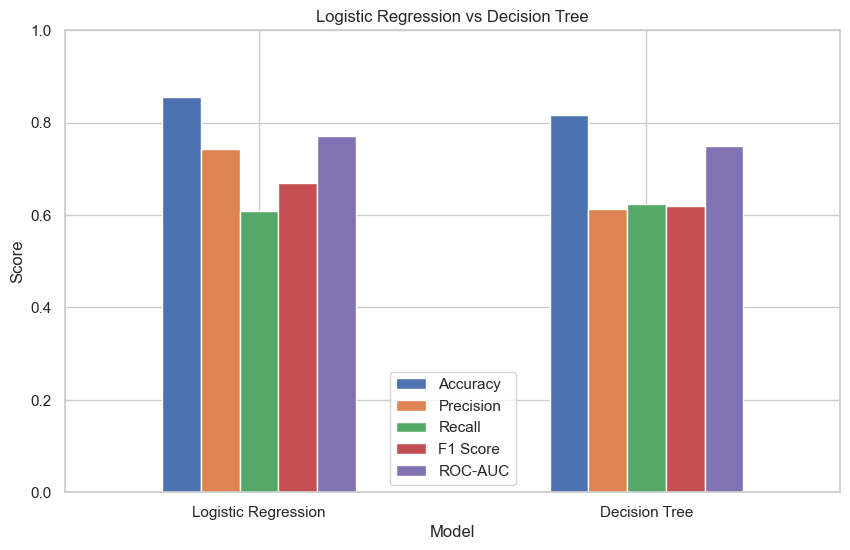

In [50]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Logistic Regression vs Decision Tree")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

#### Final Model Selection

Based on the evaluation results, **Logistic Regression** was selected as the final model.

It achieved an accuracy of **85.61%** and a ROC-AUC score of **77.15%**, which were higher than the Decision Tree model. It also achieved higher Precision and F1 Score.

Although the Decision Tree achieved a slightly higher Recall (**62.47%** compared with **60.93%**), Logistic Regression showed stronger overall performance across most evaluation metrics.

Therefore, Logistic Regression was selected as the final model for this project.

## 13. Feature Importance

In [51]:
model = dectree.named_steps["model"]

preprocessor_fitted = dectree.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
19,nominal__marital-status_Married-civ-spouse,0.200592
1,num__fnlwgt,0.187873
2,num__education-num,0.127218
3,num__capital-gain,0.105451
0,num__age,0.095486
5,num__hours-per-week,0.063397
4,num__capital-loss,0.041197
6,ordinal__age_group,0.012759
27,nominal__occupation_Exec-managerial,0.009050
11,nominal__workclass_Private,0.008714


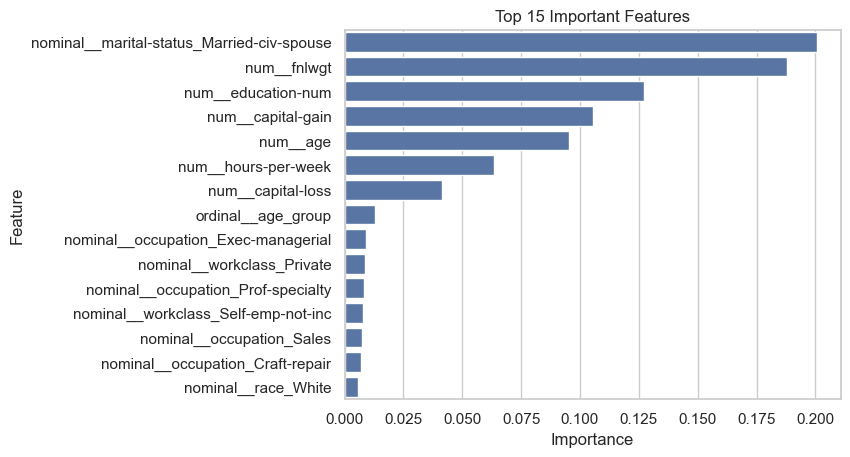

In [52]:
top_features = feature_importance.head(15)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 14. Final Conclusion

This project developed two machine learning classification models, **Logistic Regression** and **Decision Tree**, to predict whether an individual's annual income is `<=50K` or `>50K`.

The dataset was cleaned and preprocessed by handling missing values, removing redundant information, encoding categorical variables, and scaling numerical features where appropriate.

Both models were evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix.

### Model Comparison

Based on the evaluation results:

- Logistic Regression achieved an Accuracy of **85.61%** and an F1-score of **66.96%**.
- Decision Tree achieved an Accuracy of **81.57%** and an F1-score of **61.88%**.
- The model with the higher overall ROC-AUC was **Logistic Regression**.

### Final Insight

The comparison demonstrates that different classification algorithms can capture different patterns within the same dataset.

**Logistic Regression** was selected as the preferred model because it provided the strongest overall performance based on the evaluation metrics.

The analysis also showed that several demographic and employment-related characteristics contain useful predictive information for income classification.
